# Heatmap results

In [1]:
%%capture

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex
import seaborn as sns

import plotly.express as px
import pandas as pd
import numpy as np
import base64
from PIL import Image
from io import BytesIO
from IPython.display import HTML

import pandas as pd
import numpy as np
import plotly.graph_objs as go
from ipywidgets import Output
from IPython.display import display, Image as IPImage
from IPython.display import FileLink

from ipywidgets import Dropdown, interact, Checkbox, VBox, HBox, Label, widgets, RadioButtons

**Select group name**

In [3]:
# Select group
groups = os.listdir(os.path.join('..', 'work_directory', 'inference_directory', 'outputs'))
# Create a Dropdown widget
dropdown = Dropdown(
    options=groups,
    value=groups[0],  # Default selected value
    description='Select:',
    disabled=False,
)
display(dropdown)

# Variable to store the selected option
group = dropdown.value

# Function to update the variable when the dropdown value changes
def on_change(change):
    global group  # Declare as global to update the variable
    group = change['new']  # Save the selected option to the variable
    print(f"Selected group saved: {group}")

# Observe the dropdown for changes
dropdown.observe(on_change, names='value')

Dropdown(description='Select:', options=('slice_mouse_kidney',), value='slice_mouse_kidney')

**Select task name**

In [5]:
# Select task
tasks = os.listdir(os.path.join('..', 'work_directory', 'inference_directory', 'outputs', group))
# Create a Dropdown widget
dropdown = Dropdown(
    options=tasks,
    value=tasks[0],  # Default selected value
    description='Select:',
    disabled=False,
)
display(dropdown)

# Variable to store the selected option
task = dropdown.value

# Function to update the variable when the dropdown value changes
def on_change(change):
    global task  # Declare as global to update the variable
    task = change['new']  # Save the selected option to the variable
    print(f"Selected group saved: {task}")

# Observe the dropdown for changes
dropdown.observe(on_change, names='value')

Dropdown(description='Select:', options=('slice_models',), value='slice_models')

**Select model name**

In [6]:
# Select model
model_list = os.listdir(os.path.join('..', 'work_directory', 'inference_directory', 'outputs', group, task, 'umap'))

model_list = [i.replace('.csv', '') for i in model_list]
# Create a Dropdown widget
dropdown = Dropdown(
    options=model_list,
    value=model_list[0],  # Default selected value
    description='Select:',
    disabled=False,
)
display(dropdown)

# Variable to store the selected option
model_name = dropdown.value

# Function to update the variable when the dropdown value changes
def on_change(change):
    global model_name  # Declare as global to update the variable
    model_name = change['new']  # Save the selected option to the variable
    print(f"Selected model saved: {model_name}")

# Observe the dropdown for changes
dropdown.observe(on_change, names='value')

Dropdown(description='Select:', options=('slice_models_models_v6_slice_models', 'slice_models_models_v8_slice_…

**Model metrics**

In [7]:
# Model metrics
model_outputs = os.listdir(os.path.join('..', 'work_directory', 'train_directory', 'outputs', group, task, 'models'))
model_number = model_name.split('models_v')[1].split('_')[0]
report_name = list(filter(lambda p: 'report' in p, model_outputs))[0]
with open (f'../work_directory/train_directory/outputs/{group}/{task}/models/{report_name}') as f:
    results = f.read()
print('model_v' + '\n'.join(list(filter(lambda p: p.split('\n')[0] == model_number, results.split('models_v')))[0].split('\n')[:-1]))

model_v8
S9 S3 S5
              precision    recall  f1-score   support

    inferior       0.85      0.94      0.89      1034
      middle       0.97      0.92      0.94      1034
    superior       0.85      0.81      0.83      1034

    accuracy                           0.89      3102
   macro avg       0.89      0.89      0.89      3102
weighted avg       0.89      0.89      0.89      3102

[[971   4  59]
 [  0 950  84]
 [173  27 834]]


# Show image and heatmaps

In [8]:
# Load umap data
umap_df = pd.read_csv(os.path.join('..', 'work_directory', 'inference_directory', 'outputs', group, task, 'umap', f'{model_name}.csv'))

**Choose colormap for heatmap**

In [9]:
# Heatmap colormaps
# Define options for the radio buttons
options = ['Colorfull heatmap', 'One color heatmap']

# Create a RadioButtons widget
radio_buttons = RadioButtons(
    options=options,
    value=options[0],  # Default selected option
    description='Select:',
    disabled=False
)
# Display the radio buttons
display(VBox([radio_buttons]))

# Variable to store the selected option
selected_heatmap_colors = radio_buttons.value

# Update the variable dynamically
def on_radio_change(change):
    global selected_heatmap_colors
    selected_heatmap_colors = change['new']

radio_buttons.observe(on_radio_change, names='value')

In [10]:
# Filter df
if selected_heatmap_colors == 'Colorfull heatmap':
      umap_df['heatmap_path_layer4'] = umap_df['heatmap_path_full']
      umap_df['heatmap_path_layer3'] = umap_df['heatmap_path_full'].apply(lambda p: p.replace('layer_4', 'layer_3'))
      umap_df['heatmap_path_layer2'] = umap_df['heatmap_path_full'].apply(lambda p: p.replace('layer_4', 'layer_2'))
else:
      umap_df['heatmap_path_layer4'] = umap_df['heatmap_path_one']
      umap_df['heatmap_path_layer3'] = umap_df['heatmap_path_one'].apply(lambda p: p.replace('layer_4', 'layer_3'))
      umap_df['heatmap_path_layer2'] = umap_df['heatmap_path_one'].apply(lambda p: p.replace('layer_4', 'layer_2'))

class_mapping = {cls: idx for idx, cls in enumerate(umap_df['class_name'].unique())}
umap_df['class_numeric'] = umap_df['class_name'].map(class_mapping)

**Choose colormap for NORI**

In [11]:
# NORI colormaps
colormaps = {}
colormaps['red_green'] = [1, 2, 0]
colormaps['blue_yellow'] = [2, 2, 1]
colormaps['magenta_green'] = [1, 2, 1]
colormaps['red_blue'] = [1, 0, 2]
colormaps['green_blue'] = [0, 1, 2]
colormaps['red_cyan'] = [1, 2, 2]
colormaps['original'] = [0, 1, 2]

colormap_list = list(colormaps.keys())
# Create a Dropdown widget
dropdown = Dropdown(
    options=colormap_list,
    value=colormap_list[0],  # Default selected value
    description='Select:',
    disabled=False,
)
display(dropdown)

# Variable to store the selected option
colormap_select = dropdown.value

# Function to update the variable when the dropdown value changes
def on_change(change):
    global colormap_select  # Declare as global to update the variable
    colormap_select = change['new']  # Save the selected option to the variable
    print(f"Selected model saved: {colormap_select}")

# Observe the dropdown for changes
dropdown.observe(on_change, names='value')

Dropdown(description='Select:', options=('red_green', 'blue_yellow', 'magenta_green', 'red_blue', 'green_blue'…

**Heatmap plots**

In [12]:
# Make plots
three_layers = True
# @title
# Define Output widget to display images
output = Output()
display(output)

# Initialize FigureWidget for Plotly scatter plot
fig = go.FigureWidget(data=[
    go.Scatter(
        x=umap_df['umap1'],
        y=umap_df['umap2'],
        mode='markers',
        marker=dict(size=8, color=umap_df['class_numeric'], colorscale='Viridis'),
        customdata=umap_df[['class_name', 'image_path', 'heatmap_path_layer4', 'heatmap_path_layer3', 'heatmap_path_layer2', 'image_name']].values,
        hovertemplate=(
            "Class Name: %{customdata[0]}<br>" +
            "Coordinates: (%{x:.2f}, %{y:.2f})<br>" +
            "Image Name: %{customdata[5]}"
            "<extra></extra>"
        )
    )
],
    layout=dict(
        title='Group:' + group + ', Task:' + task + ',  model_v' + model_number,
        width=800,  # Set figure width
        height=600,  # Set figure height
        xaxis_title="UMAP1",  # Set x-axis title
        yaxis_title="UMAP2"   # Set y-axis title
    )
)

display(fig)

# Function to display images on point click
def display_images(trace, points, selector):
    if points.point_inds:
        ind = points.point_inds[0]
        (image_path,
         heatmap_path_l4,
         heatmap_path_l3,
         heatmap_path_l2,
         image_name,
         class_name,
         pred_class,
         prob_pred) = umap_df.loc[ind, ['image_path',
                                        'heatmap_path_layer4',
                                        'heatmap_path_layer3',
                                        'heatmap_path_layer2',
                                        'image_name',
                                        'class_name',
                                        'pred_class_real',
                                        'prob_class']]

        image_path = os.path.join('..', image_path)
        heatmap_path_l4 = os.path.join('..', heatmap_path_l4)
        heatmap_path_l3 = os.path.join('..', heatmap_path_l3)
        heatmap_path_l2 = os.path.join('..', heatmap_path_l2)

        with output:
            output.clear_output()  # Clear previous output
            print(f"Group: {group}")
            # print(f"Title: {image_name}")
            print(f"Image path: {image_path}")
            print(f"Class name: {class_name}")
            print(f"Predicted class: {pred_class}")
            print(f"Probability: {np.round(prob_pred, 2)}")

            original_image = Image.open(image_path)
            heatmap_image4 = Image.open(heatmap_path_l4)
            heatmap_image3 = Image.open(heatmap_path_l3)
            heatmap_image2 = Image.open(heatmap_path_l2)

            # Original image blue colors
            new_layers = colormaps[colormap_select]
            if colormap_select!='original':
                original_image_array = np.array(original_image)
                new_colormap_image = np.zeros(original_image_array.shape, dtype=np.uint8)
                for step in range(3):
                    if new_layers[step] == 1:
                        new_colormap_image[:, :, step] = original_image_array[:, :, 0]
                    elif new_layers[step] == 2:
                        new_colormap_image[:, :, step] = original_image_array[:, :, 1]
                    elif new_layers[step] == 0:
                        new_colormap_image[:, :, step] = 0
                original_image = Image.fromarray(new_colormap_image)

            # Create a subplot with 1 row and 2 columns
            if three_layers:
                fig, axes = plt.subplots(2, 2, figsize=(8, 8))
                axes[0][0].imshow(original_image)
                # axes[0].axis('off')  # Hide axis
                # axes[0].set_title(image_name)

                axes[0][1].imshow(heatmap_image2)
                axes[0][1].axis('off')  # Hide axis
                axes[0][1].set_title("layer2")

                axes[1][0].imshow(heatmap_image3)
                axes[1][0].axis('off')  # Hide axis
                axes[1][0].set_title("layer3")

                axes[1][1].imshow(heatmap_image4)
                axes[1][1].axis('off')  # Hide axis
                axes[1][1].set_title("layer4")

                plt.show()
            else:
                fig, axes = plt.subplots(1, 2, figsize=(12, 12))
                axes[0].imshow(original_image)
                # axes[0].axis('off')  # Hide axis
                axes[0].set_title(class_name)

                axes[1].imshow(heatmap_image3)
                axes[1].axis('off')  # Hide axis
                axes[1].set_title("layer3")
                plt.show()

# Attach click event handler to the figure
fig.data[0].on_click(display_images)


Output()

FigureWidget({
    'data': [{'customdata': array([['inferior',
                                    'work_directory/train_directory/outputs/slice_mouse_kidney/slice_models/tiles/S9/S9_fullpanel_translated_1440_7360.jpg',
                                    'work_directory/inference_directory/outputs/slice_mouse_kidney/slice_models/heatmaps/slice_models_models_v8/inferior/layer_4/full_color/S9_fullpanel_translated_1440_7360.jpg',
                                    'work_directory/inference_directory/outputs/slice_mouse_kidney/slice_models/heatmaps/slice_models_models_v8/inferior/layer_3/full_color/S9_fullpanel_translated_1440_7360.jpg',
                                    'work_directory/inference_directory/outputs/slice_mouse_kidney/slice_models/heatmaps/slice_models_models_v8/inferior/layer_2/full_color/S9_fullpanel_translated_1440_7360.jpg',
                                    'S9_fullpanel_translated_1440_7360.jpg'],
                                   ['inferior',
                  

**Static UMAP plot**

In [27]:
colors_for_plot = ["blue", "yellow", "pink", "lightgreen"]

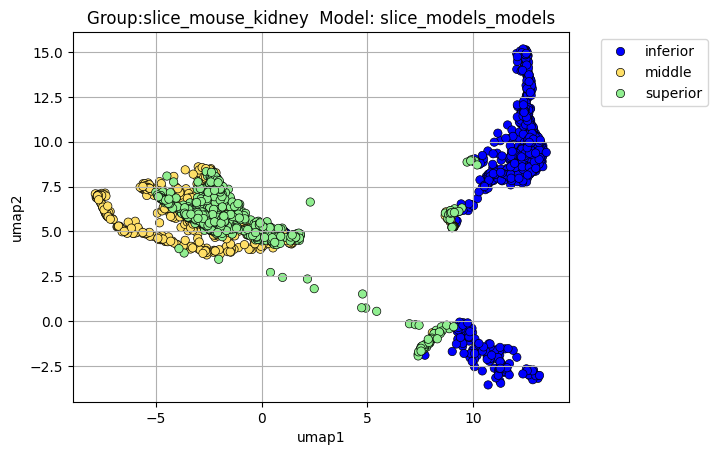

In [28]:
# Make UMAP plot
custom_cmap = LinearSegmentedColormap.from_list("colormap_matlab", colors_for_plot)
# Get unique classes and assign colors from the colormap
unique_classes = umap_df['class_name'].unique()
num_classes = len(unique_classes)

# Generate discrete colors from the colormap
color_list = [to_hex(custom_cmap(i / (num_classes - 1))) for i in range(num_classes)]

# Create a dictionary mapping class names to colors
palette_dict = dict(zip(unique_classes, color_list))

sns.scatterplot(data=umap_df, x='umap1', y='umap2', hue='class_name', palette=palette_dict, edgecolor='black')
plt.grid()
plt.title('Group:' + group + '  Model: ' + '_'.join(model_name.split('_')[:3]) )

xaxis_info = fig.to_dict()['layout']['xaxis']
yaxis_info = fig.to_dict()['layout']['yaxis']

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Added this line
xaxis_info = fig.to_dict()['layout']['xaxis']
yaxis_info = fig.to_dict()['layout']['yaxis']

if 'range' in xaxis_info.keys():
    plt.xlim(xaxis_info['range'])
if 'range' in yaxis_info.keys():
    plt.ylim(yaxis_info['range'])

In [16]:
np.unique(umap_df['pred_class_real'], return_counts=True)

(array([0, 1, 2]), array([2031,  935,  136]))

In [18]:
np.unique(umap_df['class_name'], return_counts=True)

(array(['inferior', 'middle', 'superior'], dtype=object),
 array([1034, 1034, 1034]))